In [29]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df=pd.read_csv('Target.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   620 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

**Task 1: Data Cleaning and Preparation**

In [31]:
# Remove duplicate or inconsistent survey responses.
initial_shape = df.shape
df.drop_duplicates(inplace=True)
print(f"Removed {initial_shape[0] - df.shape[0]} duplicate rows. Current shape: {df.shape}")

# Rename duplicate or misformatted columns , remove trailing spaces
df = df.rename(columns={
    'Personalized_Recommendation_Frequency ': 'Personalized_Recommendation_Rating',
    'Rating_Accuracy ': 'Rating_Accuracy'
})
df.columns = df.columns.str.strip()

# Handle missing values :Product_Search_Method contains missing entries (fill with 'Not Specified' or Mode)
df['Product_Search_Method'] = df['Product_Search_Method'].fillna('Not Specified')

# Standardize categorical entries
str_cols = df.select_dtypes(include='object').columns
for c in str_cols:
    df[c] = df[c].str.strip()

#Standardize numerical entries
numeric_rating_cols = ['Customer_Reviews_Importance','Rating_Accuracy','Shopping_Satisfaction','Personalized_Recommendation_Rating','age']
for c in numeric_rating_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")




Removed 0 duplicate rows. Current shape: (800, 24)


**Task 2: Descriptive Behavior Analysis**

In [32]:
#Summarize customer demographics (age, gender distribution)
print(("--customer demographics summary-- ").upper())
print(df["age"].describe())
print(df['Gender'].value_counts())
print(df["Gender"].value_counts(normalize=True).mul(100).round(1))

--CUSTOMER DEMOGRAPHICS SUMMARY-- 
count    800.000000
mean      34.737500
std       18.938306
min        3.000000
25%       18.000000
50%       34.000000
75%       50.250000
max       67.000000
Name: age, dtype: float64
Gender
Male                 214
Female               201
Others               196
Prefer not to say    189
Name: count, dtype: int64
Gender
Male                 26.8
Female               25.1
Others               24.5
Prefer not to say    23.6
Name: proportion, dtype: float64


In [33]:
# Analyze overall purchase frequency and most popular product categories.
print("--PURCHASE FREQUENCY--")
print(df['Purchase_Frequency'].value_counts())
all_categories = df["Purchase_Categories"].dropna().str.split(";").explode().str.strip()
cat_counts = all_categories.value_counts()
print("--MOST POPULAR PRODUCT CATEGORIES--")
print(cat_counts.head(10))

--PURCHASE FREQUENCY--
Purchase_Frequency
Multiple times a week     173
Less than once a month    168
Once a month              164
Few times a month         153
Once a week               142
Name: count, dtype: int64
--MOST POPULAR PRODUCT CATEGORIES--
Purchase_Categories
Beauty and Personal Care      426
Clothing and Fashion          424
Home and Kitchen              406
Groceries and Gourmet Food    403
others                        384
Name: count, dtype: int64


In [34]:
# Identify top browsing methods and most common cart abandonment factors.
print("\n -- PRODUCT SEARCH METHOD --")
search_counts = df["Product_Search_Method"].value_counts()
print(search_counts)

print("\n-- CART ABANDONMENT FACTORS --")
abandon_counts = df["Cart_Abandonment_Factors"].value_counts()
print(abandon_counts)




 -- PRODUCT SEARCH METHOD --
Product_Search_Method
Not Specified    180
Keyword          173
others           158
Filter           157
categories       132
Name: count, dtype: int64

-- CART ABANDONMENT FACTORS --
Cart_Abandonment_Factors
High shipping costs                           216
others                                        203
Changed my mind or no longer need the item    191
Found a better price elsewhere                190
Name: count, dtype: int64


In [35]:
# Mean and median satisfaction, recommendation helpfulness, and rating accuracy.

print("-- SUMMARY STATISTICS FOR RATINGS & SATISFACTION --")

# Mapping categorical helpfulness to numeric scale (1: No, 2: Sometimes, 3: Yes)
helpfulness_map = {'No': 1, 'Sometimes': 2, 'Yes': 3}
df['Recommendation_Helpfulness_Score'] = df['Recommendation_Helpfulness'].map(helpfulness_map)
metrics = ['Shopping_Satisfaction','Rating_Accuracy','Personalized_Recommendation_Rating','Recommendation_Helpfulness_Score','Customer_Reviews_Importance']
rating_summary = df[metrics].agg(['mean', 'median', 'std', 'min', 'max']).T.round(3)
print(rating_summary)

-- SUMMARY STATISTICS FOR RATINGS & SATISFACTION --
                                     mean  median    std  min  max
Shopping_Satisfaction               2.935     3.0  1.436  1.0  5.0
Rating_Accuracy                     3.059     3.0  1.440  1.0  5.0
Personalized_Recommendation_Rating  2.981     3.0  1.450  1.0  5.0
Recommendation_Helpfulness_Score    2.000     2.0  0.814  1.0  3.0
Customer_Reviews_Importance         3.004     3.0  1.431  1.0  5.0


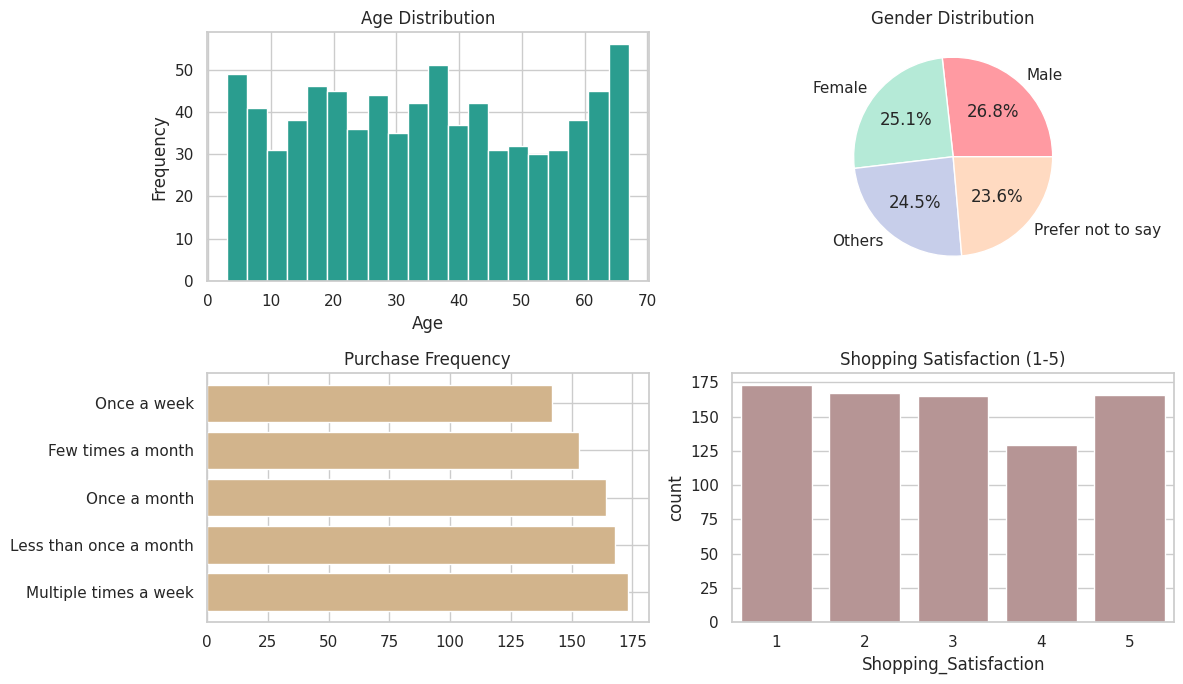

In [36]:
fig,axes=plt.subplots(2,2,figsize=(12,7))

# Age distribution
axes[0,0].hist(df['age'],bins=20,color='#2A9D8F',edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',colors=['#FF9AA2', '#B5EAD7', '#C7CEEA', '#FFDAC1'])
axes[0,1].set_title('Gender Distribution')

# Purchase frequency
pf = df['Purchase_Frequency'].value_counts()
axes[1,0].barh(pf.index, pf.values, color='tan')
axes[1,0].set_title('Purchase Frequency')

# Shopping satisfaction
sns.countplot(x='Shopping_Satisfaction', data=df, ax=axes[1,1], color='rosybrown')
axes[1,1].set_title('Shopping Satisfaction (1-5)')

plt.tight_layout()
plt.show()

**Task 3: Customer Segmentation and Profiling**

In [37]:
# Segment customers based on purchase frequency and shopping satisfaction levels
freq_order = {
    'Less than once a month': 1,
    'Once a month': 2,
    'Few times a month': 3,
    'Once a week': 4,
    'Multiple times a week': 5
}
df['Purchase_Frequency_Score'] = df['Purchase_Frequency'].map(freq_order)

def segment (row):
  if row['Purchase_Frequency_Score'] <= 2 or 'Changed my mind' in str(row['Cart_Abandonment_Factors']):
    return 'At-Risk Customers'
  elif row['Purchase_Frequency_Score'] >= 3 and row['Shopping_Satisfaction'] >= 4:
    return 'Frequent Buyers'
  else:
    return 'Occasional Shoppers'
df['Customer_Segment'] = df.apply(segment, axis=1)
print("\n --CUSTOMER SEGMENTS--")
segment_dist = pd.DataFrame({
    'Count': df['Customer_Segment'].value_counts(),
    'Percentage (%)': (df['Customer_Segment'].value_counts(normalize=True) * 100).round(2)
})
print(segment_dist)



 --CUSTOMER SEGMENTS--
                     Count  Percentage (%)
Customer_Segment                          
At-Risk Customers      450           56.25
Occasional Shoppers    225           28.12
Frequent Buyers        125           15.62


In [38]:

print("\n--DEMOGRAPHIC & BEHAVIORAL PROFILING--")

# Age by Segment
age_by_seg = df.groupby('Customer_Segment')['age'].agg(['mean']).round(2)
print("-- Age Profile by Segment-- \n", age_by_seg)

# Gender Breakdown by Segment
gender_by_seg = (pd.crosstab(df['Customer_Segment'], df['Gender'], normalize='index') * 100).round(2)
print("\n -- Gender Distribution by Segment--\n", gender_by_seg)

# Satisfaction & Scores by Segment
scores_by_seg = df.groupby('Customer_Segment')[[
    'Shopping_Satisfaction',
    'Purchase_Frequency_Score',
    'Rating_Accuracy',
    'Personalized_Recommendation_Rating'
]].mean().round(2)
print("\n--Mean Behavioral Scores by Segment--\n", scores_by_seg)


--DEMOGRAPHIC & BEHAVIORAL PROFILING--
-- Age Profile by Segment-- 
                       mean
Customer_Segment          
At-Risk Customers    34.19
Frequent Buyers      36.14
Occasional Shoppers  35.04

 -- Gender Distribution by Segment--
 Gender               Female   Male  Others  Prefer not to say
Customer_Segment                                             
At-Risk Customers     22.22  26.44   25.11              26.22
Frequent Buyers       26.40  28.00   28.80              16.80
Occasional Shoppers   30.22  26.67   20.89              22.22

--Mean Behavioral Scores by Segment--
                      Shopping_Satisfaction  Purchase_Frequency_Score  \
Customer_Segment                                                       
At-Risk Customers                     2.99                      2.16   
Frequent Buyers                       4.51                      4.02   
Occasional Shoppers                   1.94                      4.07   

                     Rating_Accuracy  Persona

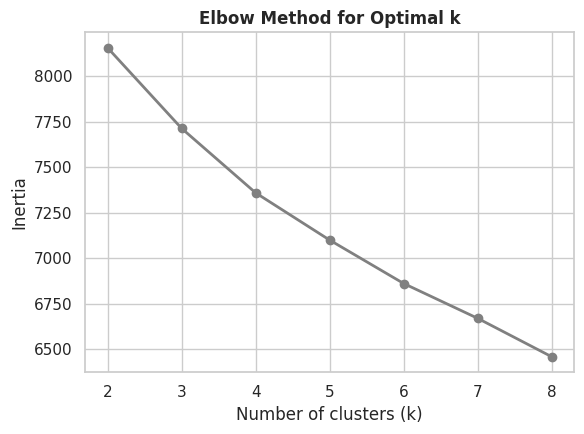

In [39]:
# clustering (e.g., K-Means) for behavioral grouping based on survey responses.

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
cluster_features_num = ['age', 'Customer_Reviews_Importance', 'Personalized_Recommendation_Rating','Rating_Accuracy', 'Shopping_Satisfaction', 'Purchase_Frequency_Score']
cluster_features_cat = ['Browsing_Frequency', 'Cart_Completion_Frequency','Saveforlater_Frequency', 'Review_Reliability', 'Add_to_Cart_Browsing']
X = df[cluster_features_num].copy()
for c in cluster_features_cat:
    le = LabelEncoder()
    X[c] = le.fit_transform(df[c])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to choose k
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(list(K_range), inertias, marker='o', color='gray', linewidth=2)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
#Fit K-Means with chosen k and visualize clusters
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes")
print(df['Cluster'].value_counts())

print("\nCluster profile ")
print(df.groupby('Cluster')[cluster_features_num].mean().round(2))



Cluster sizes
Cluster
1    285
0    273
2    242
Name: count, dtype: int64

Cluster profile 
           age  Customer_Reviews_Importance  \
Cluster                                       
0        31.26                         3.40   
1        27.36                         2.78   
2        47.35                         2.83   

         Personalized_Recommendation_Rating  Rating_Accuracy  \
Cluster                                                        
0                                      3.87             2.53   
1                                      2.40             3.65   
2                                      2.66             2.95   

         Shopping_Satisfaction  Purchase_Frequency_Score  
Cluster                                                   
0                         2.90                      2.85  
1                         2.75                      2.85  
2                         3.18                      3.29  


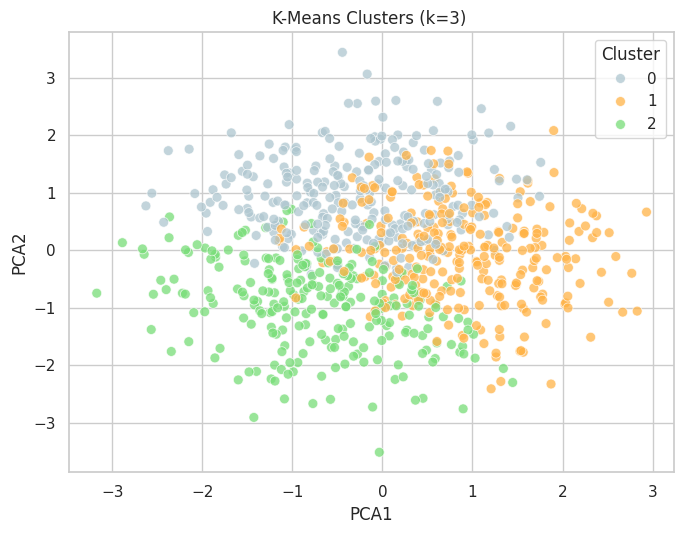

In [41]:
# PCA scatter plot of clusters
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = coords[:, 0], coords[:, 1]
light_colors = ['#AEC6CF', '#FFB347', '#77DD77', '#F49AC2', '#CBAACB']
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette=light_colors [:K_FINAL], ax=ax, alpha=0.75, s=50)
ax.set_title(f'K-Means Clusters (k={K_FINAL}) ', fontsize=12, )
plt.tight_layout()
plt.show()

**Task 4: Recommendation and Review Insights**

In [42]:
# Examine the relationship between recommendation helpfulness and shopping satisfaction
print("Shopping Satisfaction by Recommendation Helpfulness")
rec_sat = df.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].agg(['mean', 'median', 'count']).round(2)
print(rec_sat)

Shopping Satisfaction by Recommendation Helpfulness
                            mean  median  count
Recommendation_Helpfulness                     
No                          2.88     3.0    265
Sometimes                   2.98     3.0    270
Yes                         2.95     3.0    265


In [43]:
# Evaluate how review reliability and helpfulness impact overall ratings.
review_rel_summary = df.groupby('Review_Reliability').agg(
    Customer_Count=('Rating_Accuracy', 'count'),
    Mean_Rating_Accuracy=('Rating_Accuracy', 'mean'),
    Mean_Satisfaction=('Shopping_Satisfaction', 'mean')
).round(2)
print("Impact of Review Reliability on Rating :\n", review_rel_summary)

# Grouped by Review Helpfulness

review_help_summary = df.groupby('Review_Helpfulness').agg(
    Customer_Count=('Rating_Accuracy', 'count'),
    Mean_Rating_Accuracy=('Rating_Accuracy', 'mean'),
    Mean_Satisfaction=('Shopping_Satisfaction', 'mean')
).round(2)
print("\nImpact of Review Helpfulness on Rating:\n", review_help_summary)

Impact of Review Reliability on Rating :
                     Customer_Count  Mean_Rating_Accuracy  Mean_Satisfaction
Review_Reliability                                                         
Heavily                        170                  3.08               2.89
Moderately                     152                  2.94               2.88
Never                          163                  3.09               2.88
Occasionally                   150                  3.04               3.09
Rarely                         165                  3.14               2.95

Impact of Review Helpfulness on Rating:
                     Customer_Count  Mean_Rating_Accuracy  Mean_Satisfaction
Review_Helpfulness                                                         
No                             282                  3.13               2.92
Sometimes                      269                  2.99               3.06
Yes                            249                  3.05               2.81


In [44]:
# Trends in how often customers engage with or trust personalized recommendations.
rec_freq_dist = pd.DataFrame({'Count': df['Personalized_Recommendation_Frequency'].value_counts(),
                              'Percentage (%)': (df['Personalized_Recommendation_Frequency'].value_counts(normalize=True) * 100).round(2)})
print("Personalized Recommendation Frequency Engagement:\n", rec_freq_dist)

rec_rating_dist = pd.DataFrame({'Count': df['Personalized_Recommendation_Rating'].value_counts().sort_index(),
    'Percentage (%)': (df['Personalized_Recommendation_Rating'].value_counts(normalize=True).sort_index() * 100).round(2)})
print("\nPersonalized Recommendation Trust/Rating Distribution:\n", rec_rating_dist)

Personalized Recommendation Frequency Engagement:
                                        Count  Percentage (%)
Personalized_Recommendation_Frequency                       
No                                       271           33.88
Yes                                      271           33.88
Sometimes                                258           32.25

Personalized Recommendation Trust/Rating Distribution:
                                     Count  Percentage (%)
Personalized_Recommendation_Rating                       
1                                     179           22.38
2                                     147           18.38
3                                     148           18.50
4                                     162           20.25
5                                     164           20.50


In [45]:
rec_relation = pd.crosstab(
   df['Personalized_Recommendation_Frequency'],
    df['Personalized_Recommendation_Rating'],
    normalize="index"
) * 100

rec_relation.round(2)

Personalized_Recommendation_Rating,1,2,3,4,5
Personalized_Recommendation_Frequency,,,,,
No,21.77,19.56,19.93,19.56,19.19
Sometimes,24.42,20.16,16.67,19.38,19.38
Yes,21.03,15.50,18.82,21.77,22.88


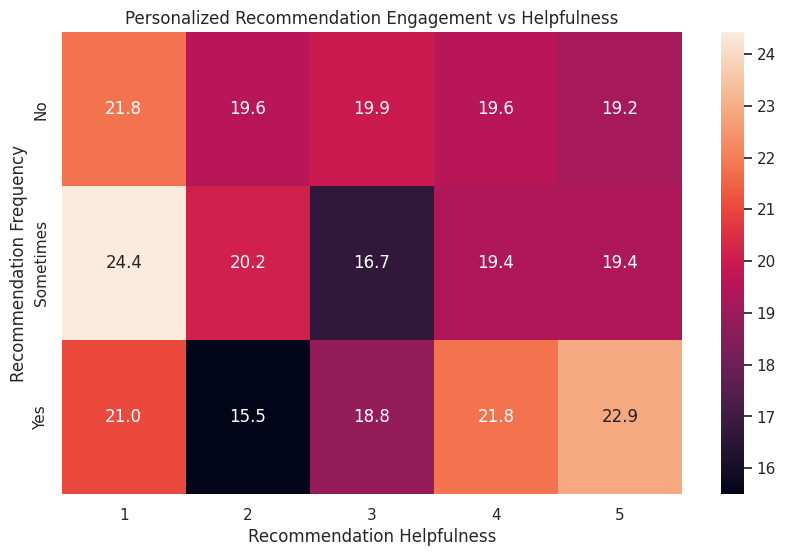

In [46]:
plt.figure(figsize=(10, 6))
sns.heatmap(rec_relation,  annot=True,fmt=".1f")

plt.title("Personalized Recommendation Engagement vs Helpfulness")
plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Recommendation Frequency")
plt.show()

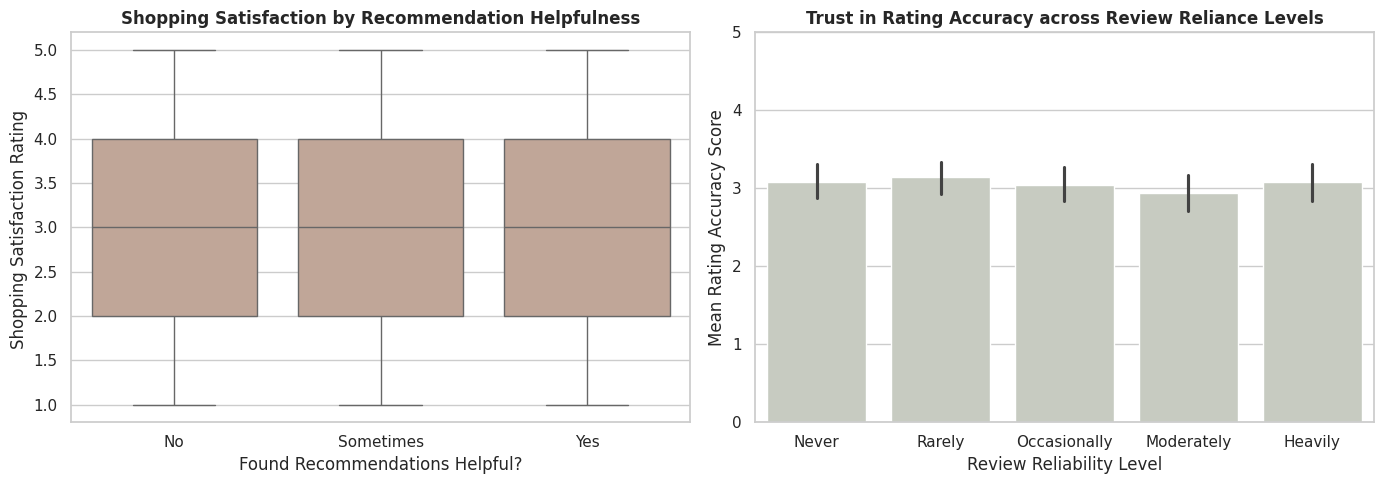

In [47]:
#  Visualizations for Insights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

#  Satisfaction across Recommendation Helpfulness
sns.boxplot(
    data=df,
    x='Recommendation_Helpfulness',
    y='Shopping_Satisfaction',
    order=['No', 'Sometimes', 'Yes'],
    color='#C7A491',
    ax=axes[0]
)
axes[0].set_title('Shopping Satisfaction by Recommendation Helpfulness', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Found Recommendations Helpful?')
axes[0].set_ylabel('Shopping Satisfaction Rating ')

#  Rating Accuracy Trust by Review Reliability Level
sns.barplot(
    data=df,
    x='Review_Reliability',
    y='Rating_Accuracy',
    order=['Never', 'Rarely', 'Occasionally', 'Moderately', 'Heavily'],
    color='#C7CDBF',
    ax=axes[1]
)
axes[1].set_title('Trust in Rating Accuracy across Review Reliance Levels', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Review Reliability Level')
axes[1].set_ylabel('Mean Rating Accuracy Score' )
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

## Task 4: Recommendation and Review Insights

- **Recommendation helpfulness vs. satisfaction:** Satisfaction stays roughly flat across "No/Sometimes/Yes" helpfulness groups — recommendations don't appear to meaningfully drive satisfaction in this sample.
- **Review reliability/helpfulness vs. rating trust:** Trust in rating accuracy barely changes regardless of how much customers rely on reviews or find them helpful — trust seems to be driven by something else.
- **Engagement trends:** Seeing recommendations more often doesn't make customers find them more helpful.

**Actionable insights:**
1. Optimize recommendations for relevance, not exposure frequency.
2. Measure recommendation success against satisfaction/repeat-purchase, not clicks or helpfulness votes.
3. Run a follow-up survey to find what actually builds rating trust, since current review metrics don't explain it.
4. Test different recommendation strategies for At-Risk vs. Frequent Buyer segments.






**Task 5: Visualization and Reporting**

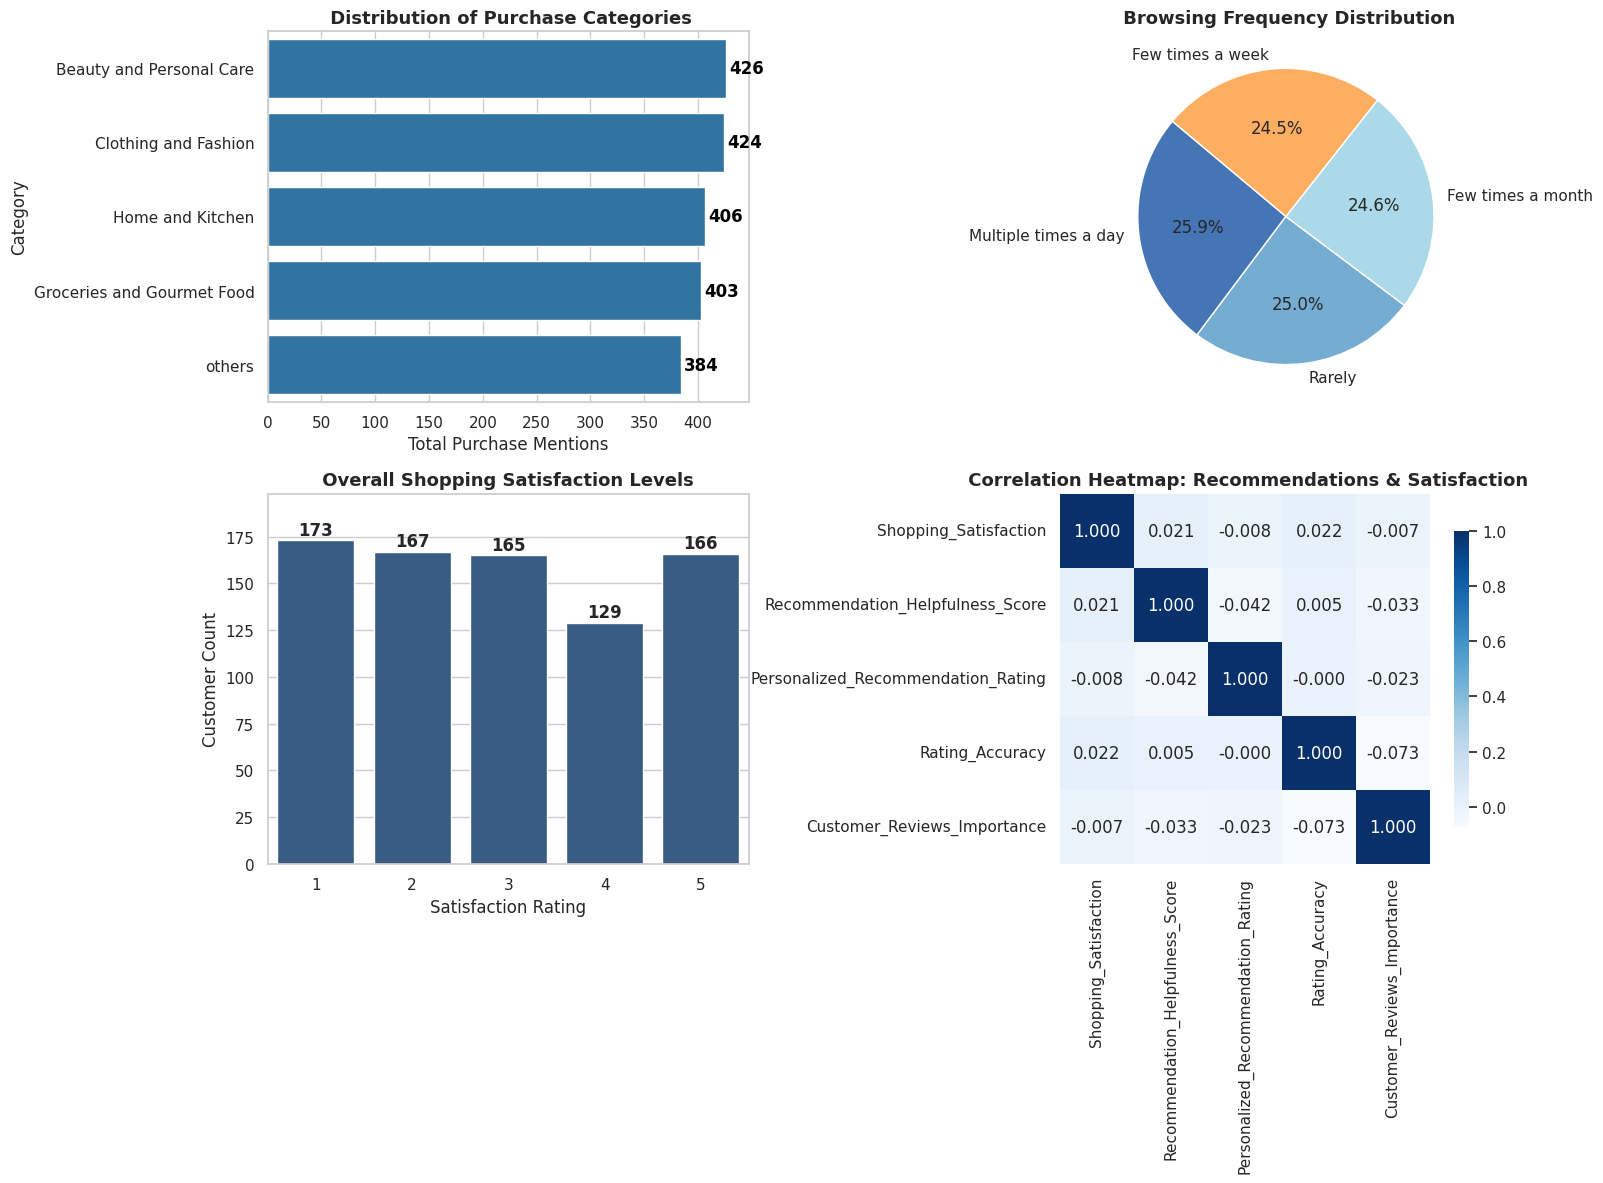

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Map categorical recommendation helpfulness to numeric score
rec_map = {'No': 1, 'Sometimes': 2, 'Yes': 3}
df['Recommendation_Helpfulness_Score'] = df['Recommendation_Helpfulness'].astype(str).str.strip().map(rec_map)

# Explode multi-valued purchase categories
categories_series = df['Purchase_Categories'].dropna().str.split(';').explode().str.strip()
cat_counts = categories_series.value_counts()

# Browsing frequency counts
browse_counts = df['Browsing_Frequency'].value_counts()

# Shopping satisfaction rating counts
sat_counts = df['Shopping_Satisfaction'].value_counts().sort_index()

# Correlation Matrix
numeric_cols = ['Shopping_Satisfaction','Recommendation_Helpfulness_Score',
                'Personalized_Recommendation_Rating','Rating_Accuracy','Customer_Reviews_Importance']
corr_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Chart 1: Purchase Categories (Bar Chart)
sns.barplot(x=cat_counts.values, y=cat_counts.index, color='#1f77b4', ax=axes[0, 0])
axes[0, 0].set_title(' Distribution of Purchase Categories', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Total Purchase Mentions')
axes[0, 0].set_ylabel('Category')
for i, v in enumerate(cat_counts.values):
    axes[0, 0].text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

# Chart 2: Browsing Frequency Distribution (Pie Chart)
axes[0, 1].pie(browse_counts.values, labels=browse_counts.index, autopct='%1.1f%%', startangle=140,
colors=['#4575b4', '#74add1', '#abd9e9', '#fdae61'])
axes[0, 1].set_title(' Browsing Frequency Distribution', fontsize=13, fontweight='bold')

# Chart 3: Overall Shopping Satisfaction Levels (Bar Chart)
sns.barplot(x=sat_counts.index, y=sat_counts.values, color='#2b5c8f', ax=axes[1, 0])
axes[1, 0].set_title(' Overall Shopping Satisfaction Levels ', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Satisfaction Rating')
axes[1, 0].set_ylabel('Customer Count')
axes[1, 0].set_ylim(0, max(sat_counts.values) + 25)
for i, v in enumerate(sat_counts.values):
    axes[1, 0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Chart 4: Correlation Heatmap (Recommendations vs Satisfaction)
sns.heatmap(corr_matrix,  annot=True,  cmap='Blues',fmt='.3f',square=True, cbar_kws={"shrink": .8}, ax=axes[1, 1])
axes[1, 1].set_title(' Correlation Heatmap: Recommendations & Satisfaction', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('task5_dashboard_report.png', dpi=300)
plt.show()

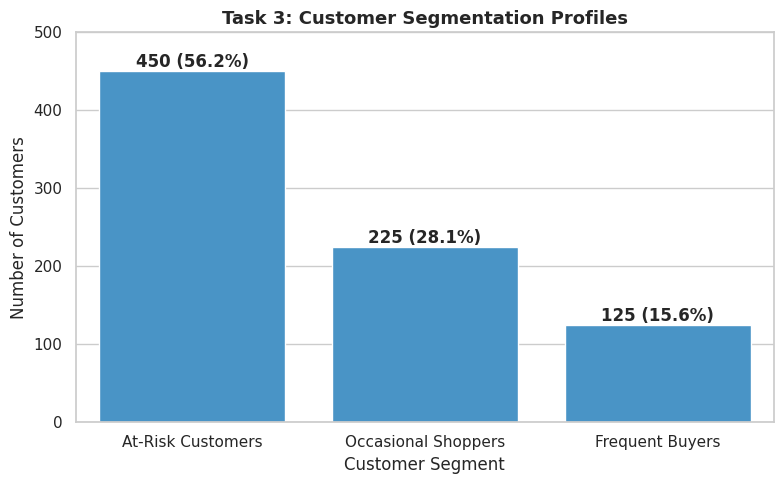

In [49]:
seg_counts = df['Customer_Segment'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=seg_counts.index, y=seg_counts.values, color='#3498db')
plt.title(
    'Task 3: Customer Segmentation Profiles', fontsize=13, fontweight='bold'
)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

for i, v in enumerate(seg_counts.values):
  pct = (v / len(df)) * 100
  plt.text(i, v + 5, f'{v} ({pct:.1f}%)', ha='center', fontweight='bold')

plt.ylim(0, max(seg_counts.values) + 50)
plt.tight_layout()
plt.savefig('task3_customer_segmentation.png', dpi=300)
plt.show()

<Figure size 800x500 with 0 Axes>

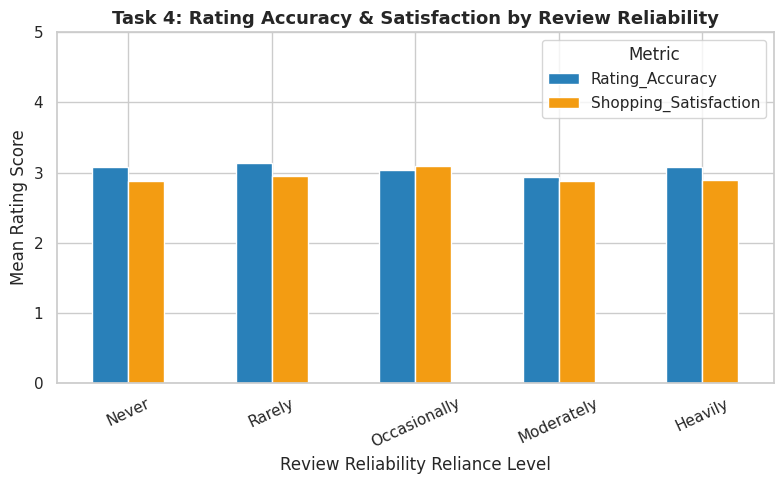

In [50]:
task4_data = (
    df.groupby('Review_Reliability')
    [['Rating_Accuracy', 'Shopping_Satisfaction']].mean().loc[['Never', 'Rarely', 'Occasionally', 'Moderately', 'Heavily']])

plt.figure(figsize=(8, 5))
task4_data.plot(kind='bar', color=['#2980b9', '#f39c12'], figsize=(8, 5))
plt.title('Task 4: Rating Accuracy & Satisfaction by Review Reliability',fontsize=13,fontweight='bold',)
plt.xlabel('Review Reliability Reliance Level')
plt.ylabel('Mean Rating Score')
plt.ylim(0, 5)
plt.xticks(rotation=25)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('task4_review_reliability.png', dpi=300)
plt.show()